<a href="https://colab.research.google.com/github/yeonji200522-oss/Hands-on-Machine-Learning/blob/main/%EA%B2%B0%EA%B3%BC_%EB%BD%91%EA%B8%B05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from collections import OrderedDict
from google.colab import drive

# ============================================================
# 1. 데이터 로드
# ============================================================
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/!Seoul_Aprtment_FINAL.xlsx'
df_raw = pd.read_excel(file_path)

# ============================================================
# [함수 1] 전처리 (로그 제거: Size, Population 모두 Level)
# ============================================================
def prepare_seoul_df_final(df_input):
    df = df_input.copy()

    # Size
    if "Size_m2" in df.columns:
        df["Size_Level"] = df["Size_m2"]

    # Population Density
    if "Pop. Density" in df.columns:
        df["Pop_Density_Level"] = df["Pop. Density"]

    # Units
    if "num_of_people" in df.columns:
        df["Units_Level"] = df["num_of_people"]

    # 비율 변수
    age_map = {
        "Median age": "Medium_age_ratio",
        "Old Population": "Old_pop_ratio",
        "Sex_ratio": "Sex_ratio_ratio"
    }
    for original, new in age_map.items():
        if original in df.columns:
            df[new] = df[original] / 100.0 if df[original].max() > 2.0 else df[original]

    # 입지 변수
    if "Dist_CBD" in df.columns:
        df["Dist_CBD_km"] = df["Dist_CBD"] / 1000.0

    if "heating" in df.columns:
        df["Heating_Dummy"] = df["heating"].astype(str).apply(
            lambda x: 1 if '도시가스' in x else 0
        )

    # 계절
    if "Month_Sold" in df.columns:
        m = pd.to_numeric(df["Month_Sold"], errors="coerce")
        df["Spring"] = m.isin([3, 4, 5]).astype(int)
        df["Fall"]   = m.isin([9, 10, 11]).astype(int)
        df["Winter"] = m.isin([12, 1, 2]).astype(int)

    # 좌표명 통일
    df = df.rename(columns={"Latitude": "y", "Longitude": "x"})

    return df


# ============================================================
# [함수 2] Spatial Lag (WY)
# ============================================================
def compute_WY_final(df_sub, dist_band=1.0):
    if len(df_sub) < 2:
        return np.zeros(len(df_sub))

    lat = df_sub['y'].values
    lon = df_sub['x'].values
    Y = df_sub['Log_Price_per_m2'].values

    g = pd.DataFrame({"y": lat, "x": lon, "Y": Y}) \
        .groupby(["y", "x"])["Y"].agg(["sum", "count"]).reset_index()

    lat_r = np.deg2rad(g["y"].values)
    lon_r = np.deg2rad(g["x"].values)

    tree = BallTree(np.column_stack([lat_r, lon_r]), metric="haversine")

    WY_uni = np.zeros(len(g))
    rad_band = dist_band / 6371.0

    for i in range(len(g)):
        idx = tree.query_radius(
            np.column_stack([lat_r[i], lon_r[i]]),
            r=rad_band * 1.000001
        )[0]

        idx = idx[idx != i]

        if idx.size > 0:
            d = 6371.0 * 2.0 * np.arcsin(
                np.sqrt(
                    np.sin((lat_r[idx]-lat_r[i])/2)**2 +
                    np.cos(lat_r[i]) * np.cos(lat_r[idx]) *
                    np.sin((lon_r[idx]-lon_r[i])/2)**2
                )
            )

            mask = (d <= dist_band) & (d > 0)

            if np.any(mask):
                invd = 1.0 / d[mask]
                WY_uni[i] = np.sum(invd * g["sum"].values[idx[mask]]) / \
                            np.sum(invd * g["count"].values[idx[mask]])

    g["_wy_val"] = WY_uni

    return df_sub.merge(
        g[["y", "x", "_wy_val"]],
        on=["y", "x"],
        how="left"
    )["_wy_val"].values


# ============================================================
# [메인 실행]
# ============================================================
df_all = prepare_seoul_df_final(df_raw)

# Feature 리스트
features = [
    "Size_Level", "Floor", "Units_Level", "Parking_per_Household", "Construction_Year",
    "Log_Dist_Subway", "Log_Dist_Green", "Log_Dist_Water", "Dist_CBD_km",
    "Sex_ratio_ratio", "Pop_Density_Level", "Medium_age_ratio", "Old_pop_ratio",
    "Spring", "Fall", "Winter"
]

results_final = {}
scaler = StandardScaler()

for year in [2022, 2023, 2024]:

    df_year = df_all[df_all["Year_Sold"] == year].copy()

    valid_cols = [c for c in features + ["Log_Price_per_m2", "y", "x"]
                  if c in df_year.columns]

    df_year = df_year.dropna(subset=valid_cols)

    if len(df_year) < 30:
        continue

    # 수치형만 표준화
    num_features = [
        c for c in features
        if c in df_year.columns and c not in ["Spring", "Fall", "Winter"]
    ]

    df_year[num_features] = scaler.fit_transform(df_year[num_features])

    X = sm.add_constant(
        df_year[[c for c in features if c in df_year.columns]],
        has_constant='add'
    )

    Y = df_year["Log_Price_per_m2"]

    # ========================================================
    # 1) OLS
    # ========================================================
    results_final[f"{year}_OLS"] = sm.OLS(Y, X).fit()

    # ========================================================
    # 2) Spatial Lag
    # ========================================================
    df_year["IND_spw"] = compute_WY_final(df_year)

    best_rho = 0
    min_rmse = float('inf')

    for rho in np.round(np.arange(-0.9, 1.0, 0.1), 2):
        temp_y = Y - rho * df_year["IND_spw"]
        model = sm.OLS(temp_y, X).fit()

        if model.mse_resid < min_rmse:
            min_rmse = model.mse_resid
            best_rho = rho

    Y_lag = Y - best_rho * df_year["IND_spw"]
    results_final[f"{year}_Lag"] = sm.OLS(Y_lag, X).fit()


# ============================================================
# [결과 테이블 생성]
# ============================================================
row_map = OrderedDict([
    ("Property Characteristics", None),
    ("Size", "Size_Level"),
    ("Floor", "Floor"),
    ("Units", "Units_Level"),
    ("Parking", "Parking_per_Household"),
    ("Construction Year", "Construction_Year"),

    ("Accessibility & Environment", None),
    ("Dist. Subway (Log)", "Log_Dist_Subway"),
    ("Dist. Green (Log)", "Log_Dist_Green"),
    ("Dist. Water (Log)", "Log_Dist_Water"),
    ("Dist. CBD (km)", "Dist_CBD_km"),

    ("Demographics", None),
    ("Sex Ratio", "Sex_ratio_ratio"),
    ("Pop. Density", "Pop_Density_Level"),
    ("Medium Age", "Medium_age_ratio"),
    ("Old Population", "Old_pop_ratio"),

    ("Seasonality Control", None),
    ("Spring", "Spring"),
    ("Fall", "Fall"),
    ("Winter", "Winter"),

    ("Constant", "const"),
    ("F-statistics", "F"),
    ("RMSE", "RMSE"),
    ("Adjusted R2", "AdjR2")
])


def build_comparison_table_thesis(res_dict, row_map):
    table = pd.DataFrame(index=row_map.keys(), columns=res_dict.keys())

    for col, res in res_dict.items():
        for rname, vname in row_map.items():

            if vname is None:
                table.loc[rname, col] = ""

            elif vname in res.params.index:
                val = res.params[vname]
                p = res.pvalues[vname]

                sig = "‡" if p < 0.01 else ("*" if p < 0.05 else "")
                table.loc[rname, col] = f"{val:.4f}{sig}"

            else:
                table.loc[rname, col] = "–"

        table.loc["F-statistics", col] = f"{res.fvalue:,.0f}‡"
        table.loc["RMSE", col] = f"{np.sqrt(res.mse_resid):.3f}"
        table.loc["Adjusted R2", col] = f"{res.rsquared_adj:.3f}"

    return table


# ============================================================
# 결과 출력
# ============================================================
print("\n[서울 아파트 가격 분석: Level 변수 + 표준화 적용 모델]")
display(build_comparison_table_thesis(results_final, row_map))

Mounted at /content/drive

[서울 아파트 가격 분석: Level 변수 + 표준화 적용 모델]


,2022_OLS,2022_Lag,2023_OLS,2023_Lag,2024_OLS,2024_Lag
Property Characteristics,,,,,,
Size,0.0180‡,-0.0146‡,-0.0071‡,-0.0242‡,0.0060‡,-0.0466‡
Floor,0.0524‡,0.0444‡,0.0458‡,0.0395‡,0.0472‡,0.0324‡
Units,0.1317‡,0.1033‡,0.1001‡,0.0888‡,0.0912‡,0.0789‡
Parking,0.0560‡,0.0461‡,0.0578‡,0.0481‡,0.0471‡,0.0317‡
Construction Year,-0.0026,0.0142‡,0.0103‡,0.0264‡,0.0344‡,0.0573‡
Accessibility & Environment,,,,,,
Dist. Subway (Log),-0.0482‡,-0.0102‡,-0.0724‡,-0.0408‡,-0.0702‡,-0.0014
Dist. Green (Log),0.0167‡,0.0075*,0.0164‡,0.0155‡,0.0213‡,0.0132‡
Dist. Water (Log),-0.0125‡,-0.0102‡,0.0071‡,0.0010,-0.0019,-0.0118‡


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 데이터 준비
target = "Log_Price_per_m2"
current_features = [c for c in features if c in df_all.columns]
df_rf = df_all.dropna(subset=current_features + [target])

X_rf = df_rf[current_features]
y_rf = df_rf[target]

# Train/Test 분리
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

# 모델 학습
rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train_rf, y_train_rf)

# 예측 및 평가지표 계산
rf_pred = rf_final.predict(X_test_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_pred))
rf_r2 = r2_score(y_test_rf, rf_pred)
rf_mae = mean_absolute_error(y_test_rf, rf_pred)

print("----- [Random Forest 결과] -----")
print(f"R² (결정계수): {rf_r2:.4f}")
print(f"RMSE (평균 제곱근 오차): {rf_rmse:.4f}")
print(f"MAE (평균 절대 오차): {rf_mae:.4f}")

----- [Random Forest 결과] -----
R² (결정계수): 0.8756
RMSE (평균 제곱근 오차): 0.1627
MAE (평균 절대 오차): 0.1151


In [ ]:
import xgboost as xgb

# 데이터 준비 (RF와 동일한 피처 사용)
df_xgb = df_all.dropna(subset=current_features + [target])
X_xgb = df_xgb[current_features]
y_xgb = df_xgb[target]

# Train/Test 분리
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42
)

# 모델 학습
xgb_final = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X_train_xgb, y_train_xgb)

# 예측 및 평가지표 계산
xgb_pred = xgb_final.predict(X_test_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, xgb_pred))
xgb_r2 = r2_score(y_test_xgb, xgb_pred)
xgb_mae = mean_absolute_error(y_test_xgb, xgb_pred)

print("----- [XGBoost 결과] -----")
print(f"R² (결정계수): {xgb_r2:.4f}")
print(f"RMSE (평균 제곱근 오차): {xgb_rmse:.4f}")
print(f"MAE (평균 절대 오차): {xgb_mae:.4f}")

----- [XGBoost 결과] -----
R² (결정계수): 0.9507
RMSE (평균 제곱근 오차): 0.1024
MAE (평균 절대 오차): 0.0701


In [ ]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

def diagnose_overfitting(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # 1. 예측값 산출
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # 2. 성능 지표 계산
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    # 3. 결과 출력
    print(f"[{model_name} 과적합 진단 보고서]")
    print(f"------------------------------------")
    print(f"Grit (Train) - R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
    print(f"Test  (Test)  - R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}")
    print(f"두 지표간 R² 차이: {abs(train_r2 - test_r2):.4f}")

    # 4. 판단 로직
    if train_r2 > 0.98 and (train_r2 - test_r2) > 0.05:
        print("결과: ⚠️ 과적합 가능성이 높음 (Train 성능이 과하게 높고 격차가 큼)")
    elif (train_r2 - test_r2) <= 0.02:
        print("결과: ✅ 일반화 성능 우수 (두 데이터셋 성능이 비슷함)")
    else:
        print("결과: ℹ️ 적정 수준의 학습 (격차가 존재하나 수용 가능한 범위)")
    print("\n")

# 실행 (기존에 학습된 모델 객체 사용)
diagnose_overfitting(rf_final, X_train_rf, y_train_rf, X_test_rf, y_test_rf, "Random Forest")
diagnose_overfitting(xgb_final, X_train_xgb, y_train_xgb, X_test_xgb, y_test_xgb, "XGBoost")

[Random Forest 과적합 진단 보고서]
------------------------------------
Grit (Train) - R²: 0.8891, RMSE: 0.1540
Test  (Test)  - R²: 0.8756, RMSE: 0.1627
두 지표간 R² 차이: 0.0136
결과: ✅ 일반화 성능 우수 (두 데이터셋 성능이 비슷함)


[XGBoost 과적합 진단 보고서]
------------------------------------
Grit (Train) - R²: 0.9622, RMSE: 0.0899
Test  (Test)  - R²: 0.9507, RMSE: 0.1024
두 지표간 R² 차이: 0.0115
결과: ✅ 일반화 성능 우수 (두 데이터셋 성능이 비슷함)




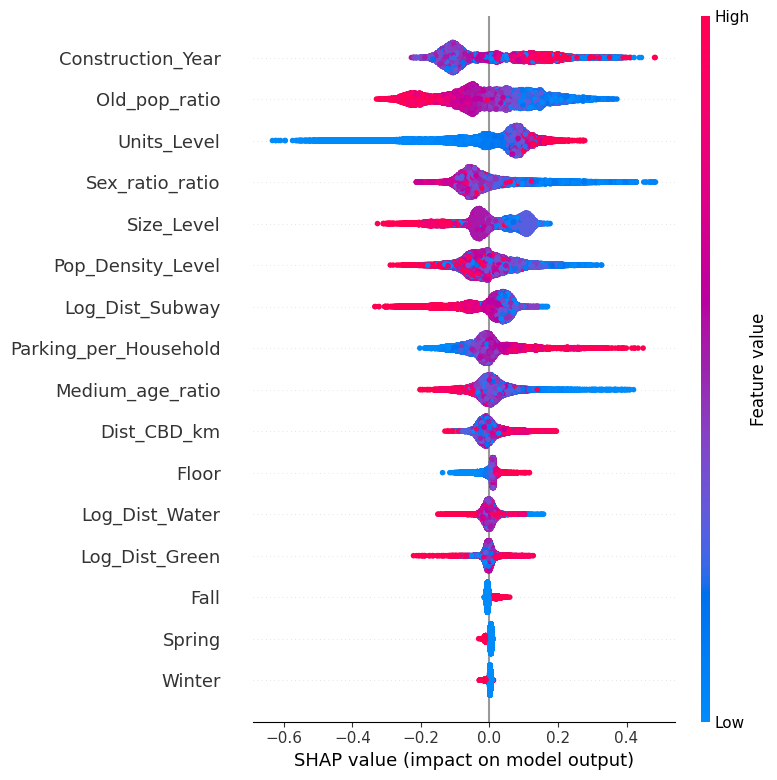

In [ ]:
!pip install shap

import shap
import matplotlib.pyplot as plt

# 1. SHAP Explainer 초기화 (XGBoost 모델 전용 TreeExplainer 사용)
explainer = shap.TreeExplainer(xgb_final)

# 2. SHAP 값 계산 (테스트 데이터셋 기준)
# 데이터가 너무 많으면 계산 시간이 오래 걸리므로 일부 샘플(예: 500개)만 추출해서 확인 가능합니다.
shap_values = explainer.shap_values(X_test_xgb)

# 3. 요약 플롯 (Summary Plot) - 전체적인 변수 영향력 파악
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_xgb, plot_type="dot")

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df, features):
    X = df[features].copy()
    X = sm.add_constant(X)

    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif_data

In [ ]:
# 다중공선성 연도별
vif_results = {}

for year in [2022, 2023, 2024]:

    df_year = df_all[df_all["Year_Sold"] == year].copy()

    valid_cols = [c for c in features if c in df_year.columns]
    df_year = df_year.dropna(subset=valid_cols)

    if len(df_year) < 30:
        continue

    # ✅ 동일하게 표준화 적용 (모델과 일관성 유지)
    num_features = [c for c in features if c not in ["Spring", "Fall", "Winter"]]
    df_year[num_features] = scaler.fit_transform(df_year[num_features])

    vif_table = compute_vif(df_year, valid_cols)

    vif_results[year] = vif_table

    print(f"\n===== {year} VIF =====")
    display(vif_table.sort_values(by="VIF", ascending=False))


===== 2022 VIF =====


,Variable,VIF
0,const,4.899493
12,Medium_age_ratio,1.909205
13,Old_pop_ratio,1.811667
14,Spring,1.780848
16,Winter,1.636848
15,Fall,1.488051
1,Size_Level,1.364075
5,Construction_Year,1.257975
4,Parking_per_Household,1.210412
3,Units_Level,1.199783



===== 2023 VIF =====


,Variable,VIF
0,const,3.022932
12,Medium_age_ratio,1.821092
13,Old_pop_ratio,1.761834
14,Spring,1.331232
15,Fall,1.304976
16,Winter,1.261106
9,Dist_CBD_km,1.186724
5,Construction_Year,1.173076
3,Units_Level,1.158549
11,Pop_Density_Level,1.139491



===== 2024 VIF =====


,Variable,VIF
0,const,2.430143
12,Medium_age_ratio,1.899869
13,Old_pop_ratio,1.864371
14,Spring,1.207402
15,Fall,1.187854
5,Construction_Year,1.169560
9,Dist_CBD_km,1.163614
16,Winter,1.163248
11,Pop_Density_Level,1.136404
3,Units_Level,1.120942


In [ ]:
# 전체 vif
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df, features):
    X = df[features].copy()
    X = sm.add_constant(X)

    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif_data
vif_table = compute_vif(df_year, valid_cols)
print(vif_table)

                 Variable       VIF
0                   const  2.430143
1              Size_Level  1.102574
2                   Floor  1.081960
3             Units_Level  1.120942
4   Parking_per_Household  1.094361
5       Construction_Year  1.169560
6         Log_Dist_Subway  1.074951
7          Log_Dist_Green  1.077103
8          Log_Dist_Water  1.075930
9             Dist_CBD_km  1.163614
10        Sex_ratio_ratio  1.063064
11      Pop_Density_Level  1.136404
12       Medium_age_ratio  1.899869
13          Old_pop_ratio  1.864371
14                 Spring  1.207402
15                   Fall  1.187854
16                 Winter  1.163248


In [ ]:
from sklearn.model_selection import train_test_split

# X, y 정의
X = df_year[features].copy()
y = df_year["Log_Price_per_m2"]

# 80% 학습, 20% 테스트
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


99

In [ ]:
#데이터 누수방지 적용 추가코드
from sklearn.model_selection import train_test_split

X = df_year[features].copy()
y = df_year["Log_Price_per_m2"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 스케일링 (누수 방지)
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 모델 생성
rf = RandomForestRegressor(
    n_estimators=100,     # 트리 개수
    max_depth=None,       # 트리 깊이 제한 (None이면 끝까지)
    random_state=42,
    n_jobs=-1             # CPU 최대 활용
)

# 학습
rf.fit(X_train, y_train)

# 예측
y_pred = rf.predict(X_test)

# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 0.0848
R2 Score: 0.9653


In [ ]:
# 트리 깊이제한 추가코드! random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 모델 생성
rf = RandomForestRegressor(
    n_estimators=300,     # 트리 개수
    max_depth=10,       # 트리 깊이 제한 10으로 바꿨어!! (None이면 끝까지)
    random_state=42,
    n_jobs=-1             # CPU 최대 활용
)

# 학습
rf.fit(X_train, y_train)

# 예측
y_pred = rf.predict(X_test)

# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

rf.feature_importances_

RMSE: 0.1585
R2 Score: 0.8791


array([4.05076491e-02, 1.06503681e-03, 1.34575419e-01, 5.11311260e-02,
       1.16512965e-01, 4.47884653e-02, 7.47434891e-03, 1.83885174e-02,
       2.80222533e-02, 1.00539778e-01, 5.85009523e-02, 9.25769937e-02,
       3.05671212e-01, 1.12171941e-04, 7.69718944e-05, 5.61393315e-05])

In [ ]:
#xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 모델 생성
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 학습
xgb.fit(X_train, y_train)

# 예측
y_pred_xgb = xgb.predict(X_test)

# 평가
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGB RMSE: {rmse:.4f}")
print(f"XGB R2: {r2:.4f}")

XGB RMSE: 0.1079
XGB R2: 0.9439


In [ ]:
# rf xg 비교
# RandomForest
rf_pred = rf.predict(X_test)

print("RandomForest R2:", r2_score(y_test, rf_pred))
print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

RandomForest R2: 0.9653460651230662
XGBoost R2: 0.9439030988759511


In [ ]:
num_features = [c for c in features if c not in ["Spring","Fall","Winter","Old_pop_ratio"]]
scaler = StandardScaler()

# 학습 데이터 기준 fit, 테스트 데이터 transform
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

In [ ]:
# ============================================================
# 1️⃣ Train / Test Split
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# X, y 정의 (Old_pop_ratio 포함)
X = df_year[features].copy()
y = df_year["Log_Price_per_m2"]

# Train/Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 수치형 변수 표준화 (더미 제외)
num_features = [c for c in features if c not in ["Spring","Fall","Winter"]]
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

# ============================================================
# 2️⃣ 모델 학습
# ============================================================
# Random Forest
rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train)

# XGBoost
xgb_model = XGBRegressor(n_estimators=500, random_state=42, objective="reg:squarederror")
xgb_model.fit(X_train, y_train)

# ============================================================
# 3️⃣ RMSE / R² 계산 함수
# ============================================================
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2   = r2_score(y, y)
    return rmse, r2

# Random Forest
rf_rmse_train, rf_r2_train = evaluate_model(rf_model, X_train, y_train)
rf_rmse_test,  rf_r2_test  = evaluate_model(rf_model, X_test, y_test)

# XGBoost
xgb_rmse_train, xgb_r2_train = evaluate_model(xgb_model, X_train, y_train)
xgb_rmse_test,  xgb_r2_test  = evaluate_model(xgb_model, X_test, y_test)

# ============================================================
# 4️⃣ 결과 표
# ============================================================
results_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Train RMSE": [rf_rmse_train, xgb_rmse_train],
    "Test RMSE": [rf_rmse_test, xgb_rmse_test],
    "Train R2": [rf_r2_train, xgb_r2_train],
    "Test R2": [rf_r2_test, xgb_r2_test]
}).set_index("Model")

print("===== Train/Test Performance =====")
display(results_df)

===== Train/Test Performance =====


,Train RMSE,Test RMSE,Train R2,Test R2
Model,,,,
Random Forest,0.031581,0.084039,1.0,1.0
XGBoost,0.040272,0.081472,1.0,1.0


In [ ]:
# randomforest
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# 수치형 변수 표준화 (더미 제외)
num_features = [c for c in features if c not in ["Spring","Fall","Winter","Old_pop_ratio"]]
scaler = StandardScaler()
df_year[num_features] = scaler.fit_transform(df_year[num_features])

# 독립변수 X, 종속변수 y
X_rf = df_year[features].copy()
y = df_year["Log_Price_per_m2"]

# Random Forest 모델
rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_model.fit(X_rf, y)

KeyboardInterrupt: 